In [7]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

%matplotlib inline

In [8]:
neighborhoods = gpd.read_file("../data/raw/MUSA_zillow_neighborhoods.geojson")

In [9]:
trees = gpd.read_file("../data/processed/philly_trees.geojson")
acerifolias = trees.loc[trees["scientific_name"] == "Platanus acerifolia"]
coords = np.radians(
    np.column_stack([acerifolias.geometry.y, acerifolias.geometry.x])
)
coords

array([[ 0.69722863, -1.31265131],
       [ 0.69722598, -1.31265276],
       [ 0.69722245, -1.31265068],
       ...,
       [ 0.69719579, -1.31263974],
       [ 0.69719691, -1.3126399 ],
       [ 0.69719978, -1.31264053]], shape=(16172, 2))

In [10]:
EARTH_RADIUS_KM = 6371.0
bandwidth_km = 0.5                       # tune this — smoothing radius
bandwidth_rad = bandwidth_km / EARTH_RADIUS_KM

kde = KernelDensity(
    bandwidth=bandwidth_rad,
    metric="haversine",
    kernel="gaussian",
    algorithm="ball_tree"
)
kde.fit(coords)
minx, miny, maxx, maxy = trees.total_bounds
n = 400
lon_grid = np.linspace(minx, maxx, n)
lat_grid = np.linspace(miny, maxy, n)
LON, LAT = np.meshgrid(lon_grid, lat_grid)
grid_rad = np.radians(np.column_stack([LAT.ravel(), LON.ravel()]))
log_density = kde.score_samples(grid_rad)
density = np.exp(log_density).reshape(LAT.shape)


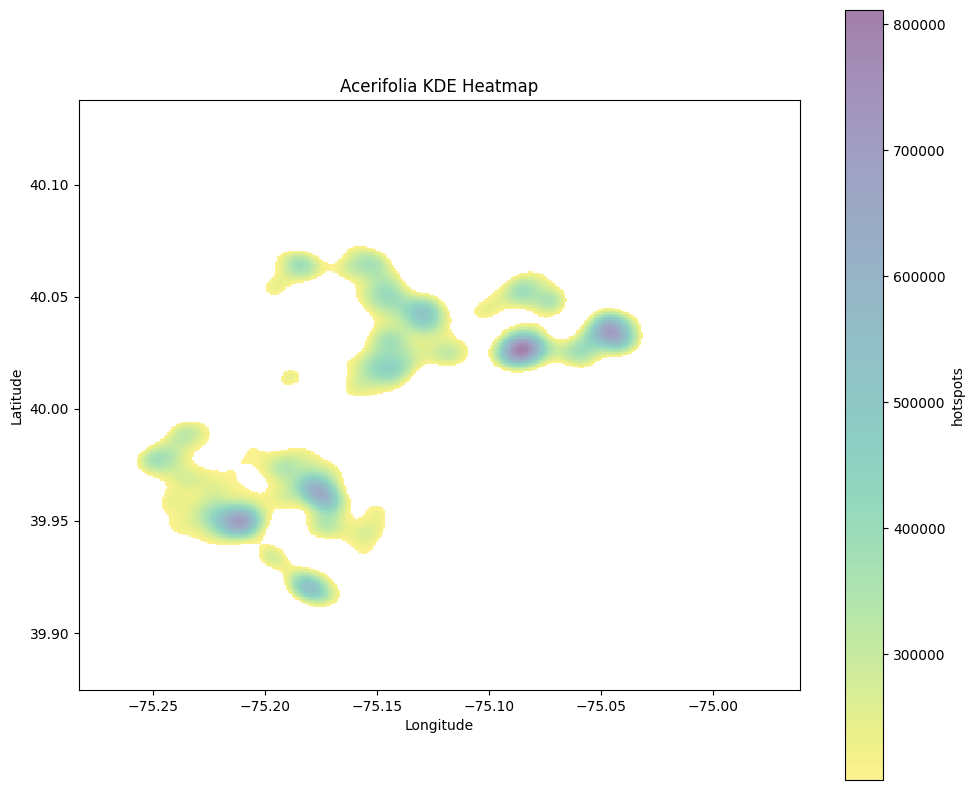

In [12]:
hotspots = np.where(density > 2e5, density, np.nan)
fig, ax = plt.subplots(figsize=(10, 8))
hm = ax.pcolormesh(LON, LAT, hotspots, 
                   cmap="viridis_r", 
                   alpha = 0.5,
                   shading="auto")
""" ax.scatter(acerifolias.geometry.x, acerifolias.geometry.y,
           s=2, c="cyan", alpha=0.3, label="accidents") """
plt.colorbar(hm, ax=ax, label="hotspots")
ax.set(xlabel="Longitude", ylabel="Latitude",
       title="Acerifolia KDE Heatmap")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()